# E-commerce A/B test project

## 1.패키지 불러오기 및 데이터 확인
- 패키지 불러오기 및 출력 옵션 설정
- 데이터 불러오기
- 데이터 구조 확인(타입, 결측치, 중복 데이터)
- 데이터 전처리

In [24]:
# ============================
# 패키지 불러오기
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ============================
# 출력 옵션 설정
# ============================

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [25]:
# ============================
# 데이터 불러오기
# ============================

commerce = pd.read_csv('/content/drive/MyDrive/ecommerce_conversion_ab_test_data.csv')

commerce.head()

,TvC,date,traffic_source,device_type,browser_language,login_y_n,region,return_y_n,conversion
0,C,2021-02-14,Referrals,Mweb,Chinese,n,Southwest,y,1
1,C,2021-02-14,Direct,Iphone,English,y,West,y,0
2,C,2021-02-11,Email Marketing,Mweb,English,y,Northeast,y,0
3,C,2021-02-11,Referrals,Iphone,English,y,Southwest,n,0
4,C,2021-02-01,Referrals,Desktop,English,y,Northeast,n,0


In [26]:
# ============================
# 데이터 구조 확인
# ============================
commerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 9 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   TvC               object
 1   date              object
 2   traffic_source    object
 3   device_type       object
 4   browser_language  object
 5   login_y_n         object
 6   region            object
 7   return_y_n        object
 8   conversion        int64 
dtypes: int64(1), object(8)
memory usage: 137.3+ MB


In [27]:
# ============================
# 결측치 확인
# ============================

commerce.isna().sum()

,0
TvC,0
date,0
traffic_source,0
device_type,0
browser_language,0
login_y_n,0
region,0
return_y_n,0
conversion,0


In [28]:
# ============================
# 중복 데이터 확인
# ============================

print(commerce.duplicated().sum())

1895422


In [29]:
# ============================
# 기본 데이터 전처리
# ============================

# date 변수를 datetime 형식으로 변환
commerce['date'] = pd.to_datetime(commerce['date'])

In [30]:
# ============================
# 데이터 확인
# ============================

# date를 제외한 변수 고유값 확인
unique_values = commerce.drop(columns="date").apply(lambda x: x.unique())
print(unique_values)

# 분석 기간 확인
commerce["date"].min(), commerce["date"].max()

TvC                                                           [C, V1]
traffic_source      [Referrals, Direct, Email Marketing, Paid Sear...
device_type                          [Mweb, Iphone, Desktop, Android]
browser_language           [Chinese, English, Spanish, French, Other]
login_y_n                                                      [n, y]
region               [Southwest, West, Northeast, Southeast, Midwest]
return_y_n                                                     [y, n]
conversion                                                     [1, 0]
dtype: object


(Timestamp('2021-02-01 00:00:00'), Timestamp('2021-02-16 00:00:00'))

## 2.EDA(범주형 변수 분포 확인)

- 단일 변수 분포 확인
- A/B 그룹별 사용자 특성 분포 확인
- 구매 전환 여부별 사용자 특성 분포 확인
- 날짜별 데이터 분포 확인


In [31]:
# ============================
# 범주형 변수 분포 시각화 함수
# ============================

def plot_count_distribution(data, columns, hue=None):
    # subplot 개수 설정
    n = len(columns)
    ncols = 2
    nrows = math.ceil(n / ncols)

    # 그래프 영역 생성
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 5*nrows)
    )

    axes = axes.flatten()

    # 변수별 countplot 생성
    for i, col in enumerate(columns):
        ax = axes[i]

        # 변수별 빈도 기준 정렬
        order = data[col].value_counts().index


        # 범주형 변수 분포 시각화
        sns.countplot(
            data=data,
            x=col,
            hue=hue,
            order=order,
            ax=ax
        )

        # 전체 데이터 기준 비율 계산
        total = len(data[col])


        # 막대별 개수 및 비율 라벨 표시
        for container in ax.containers:

            labels = [
                f'{int(v)}\n({v/total:.1%})'
                if not np.isnan(v)
                else ''
                for v in container.datavalues
            ]

            ax.bar_label(
                container,
                labels=labels,
                fontsize=8
            )

        # 그래프 제목 설정
        title = col if hue is None else f'{col} by {hue}'
        ax.set_title(title)

        # x축 라벨 회전
        ax.tick_params(
            axis='x',
            rotation=45
        )

    # 남는 subplot 제거
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    # 그래프 간격 조정 및 출력
    plt.tight_layout()
    plt.show()

### 2-1. 단일 변수 분포 확인

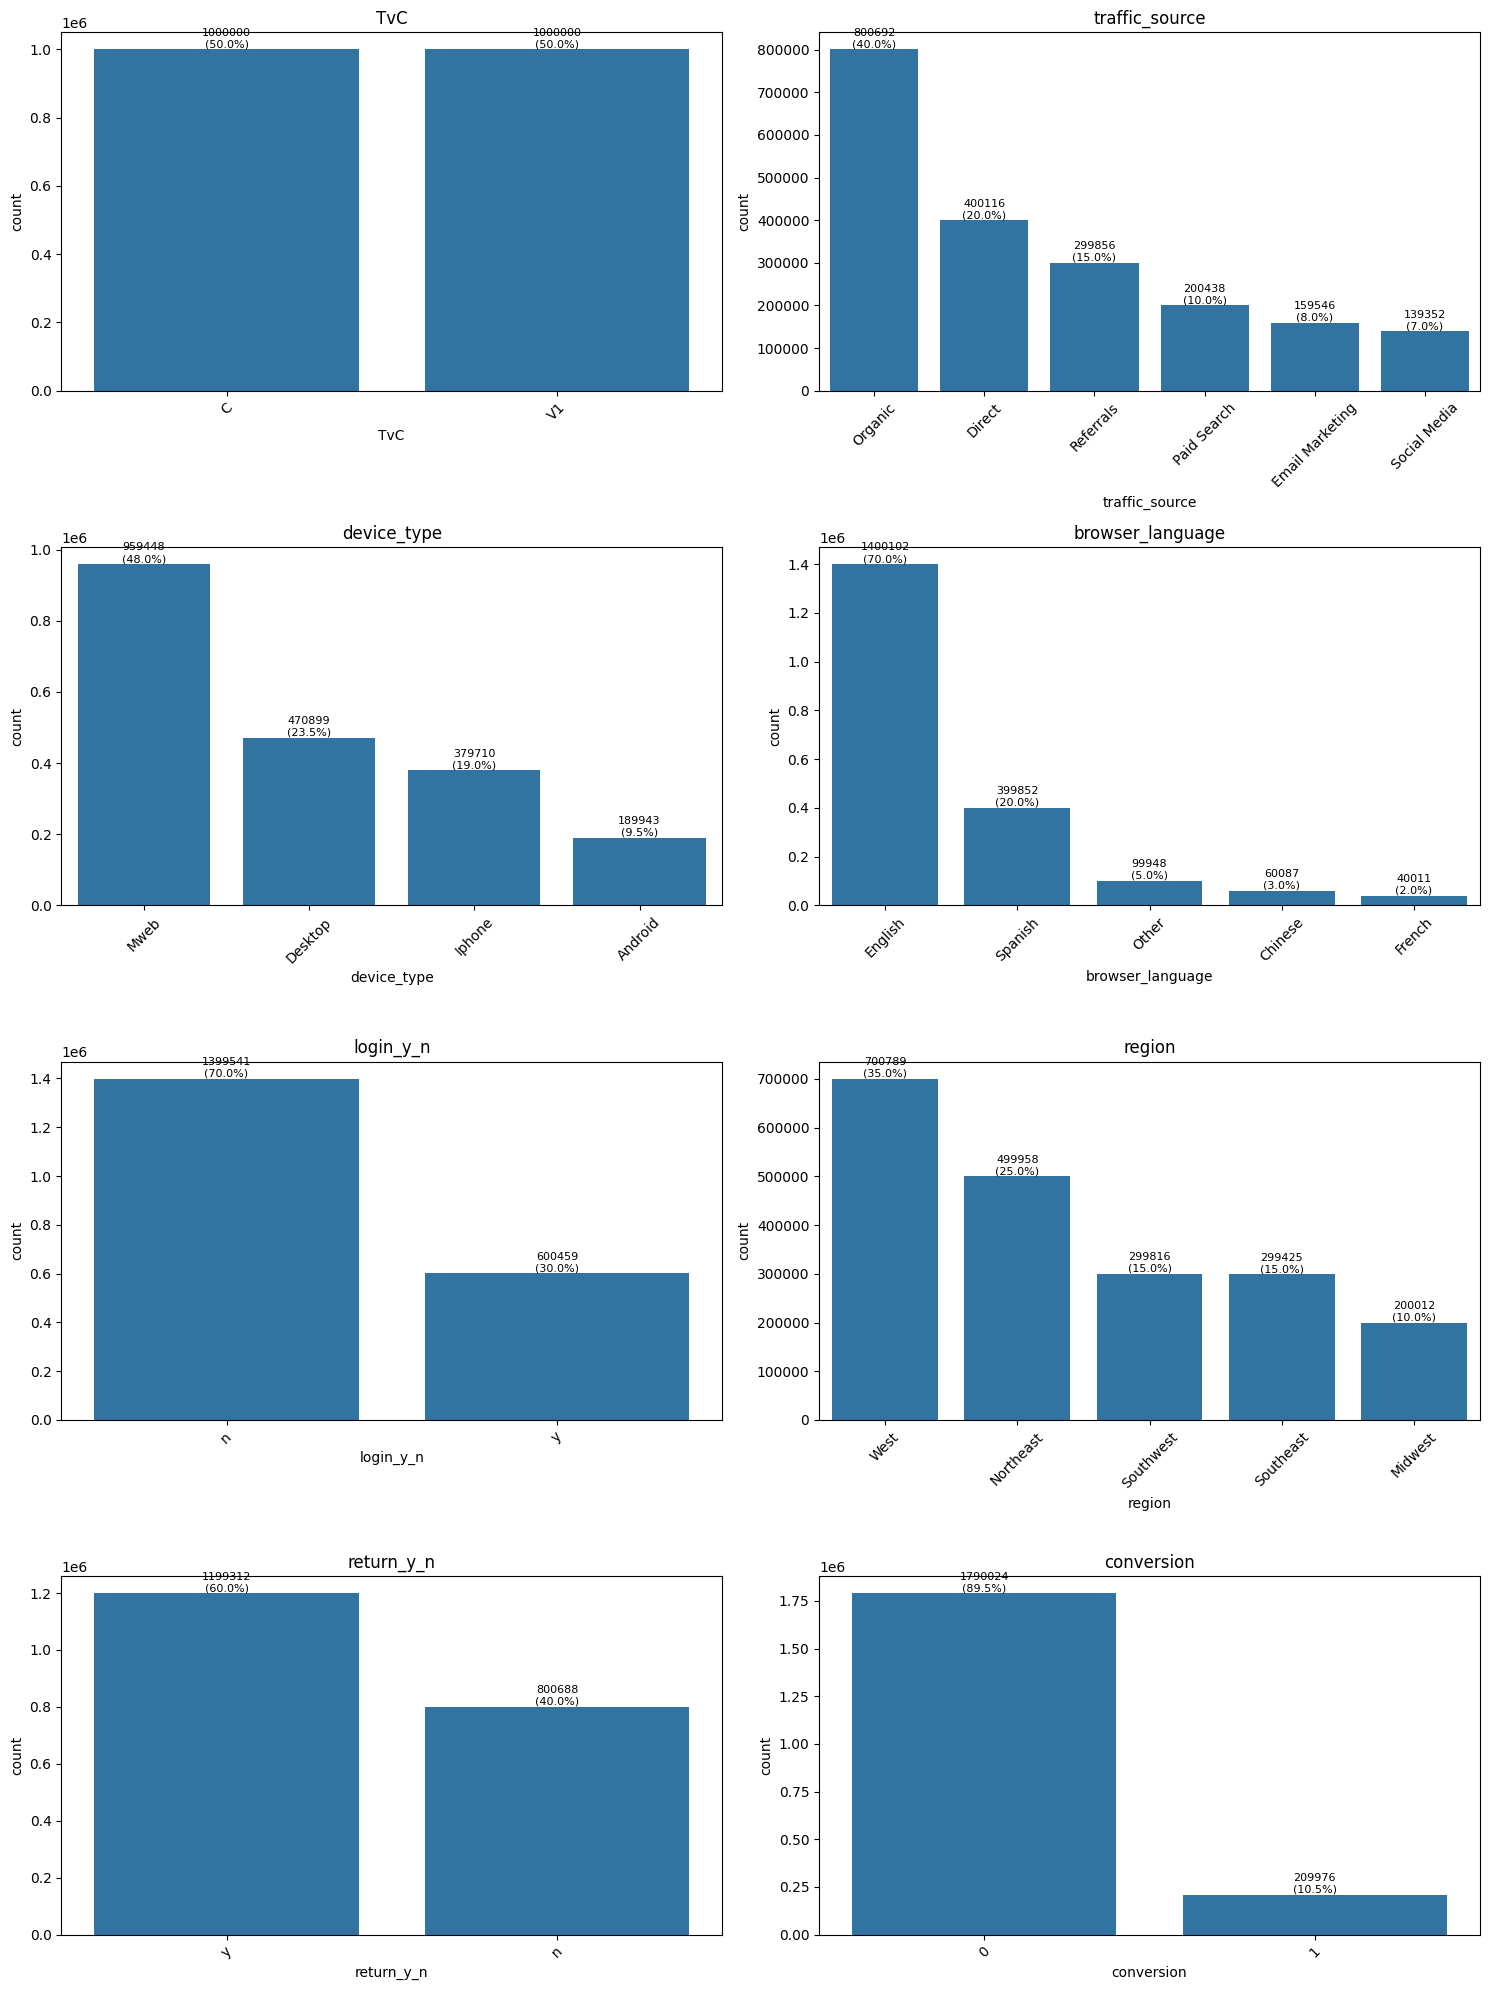

In [32]:
# ============================
# 단일 변수 분포 확인
# ============================

analysis_cols = commerce.columns.drop("date")

plot_count_distribution(
    commerce,
    analysis_cols
)

### 2-2. A/B 그룹별 사용자 특성 분포 확인

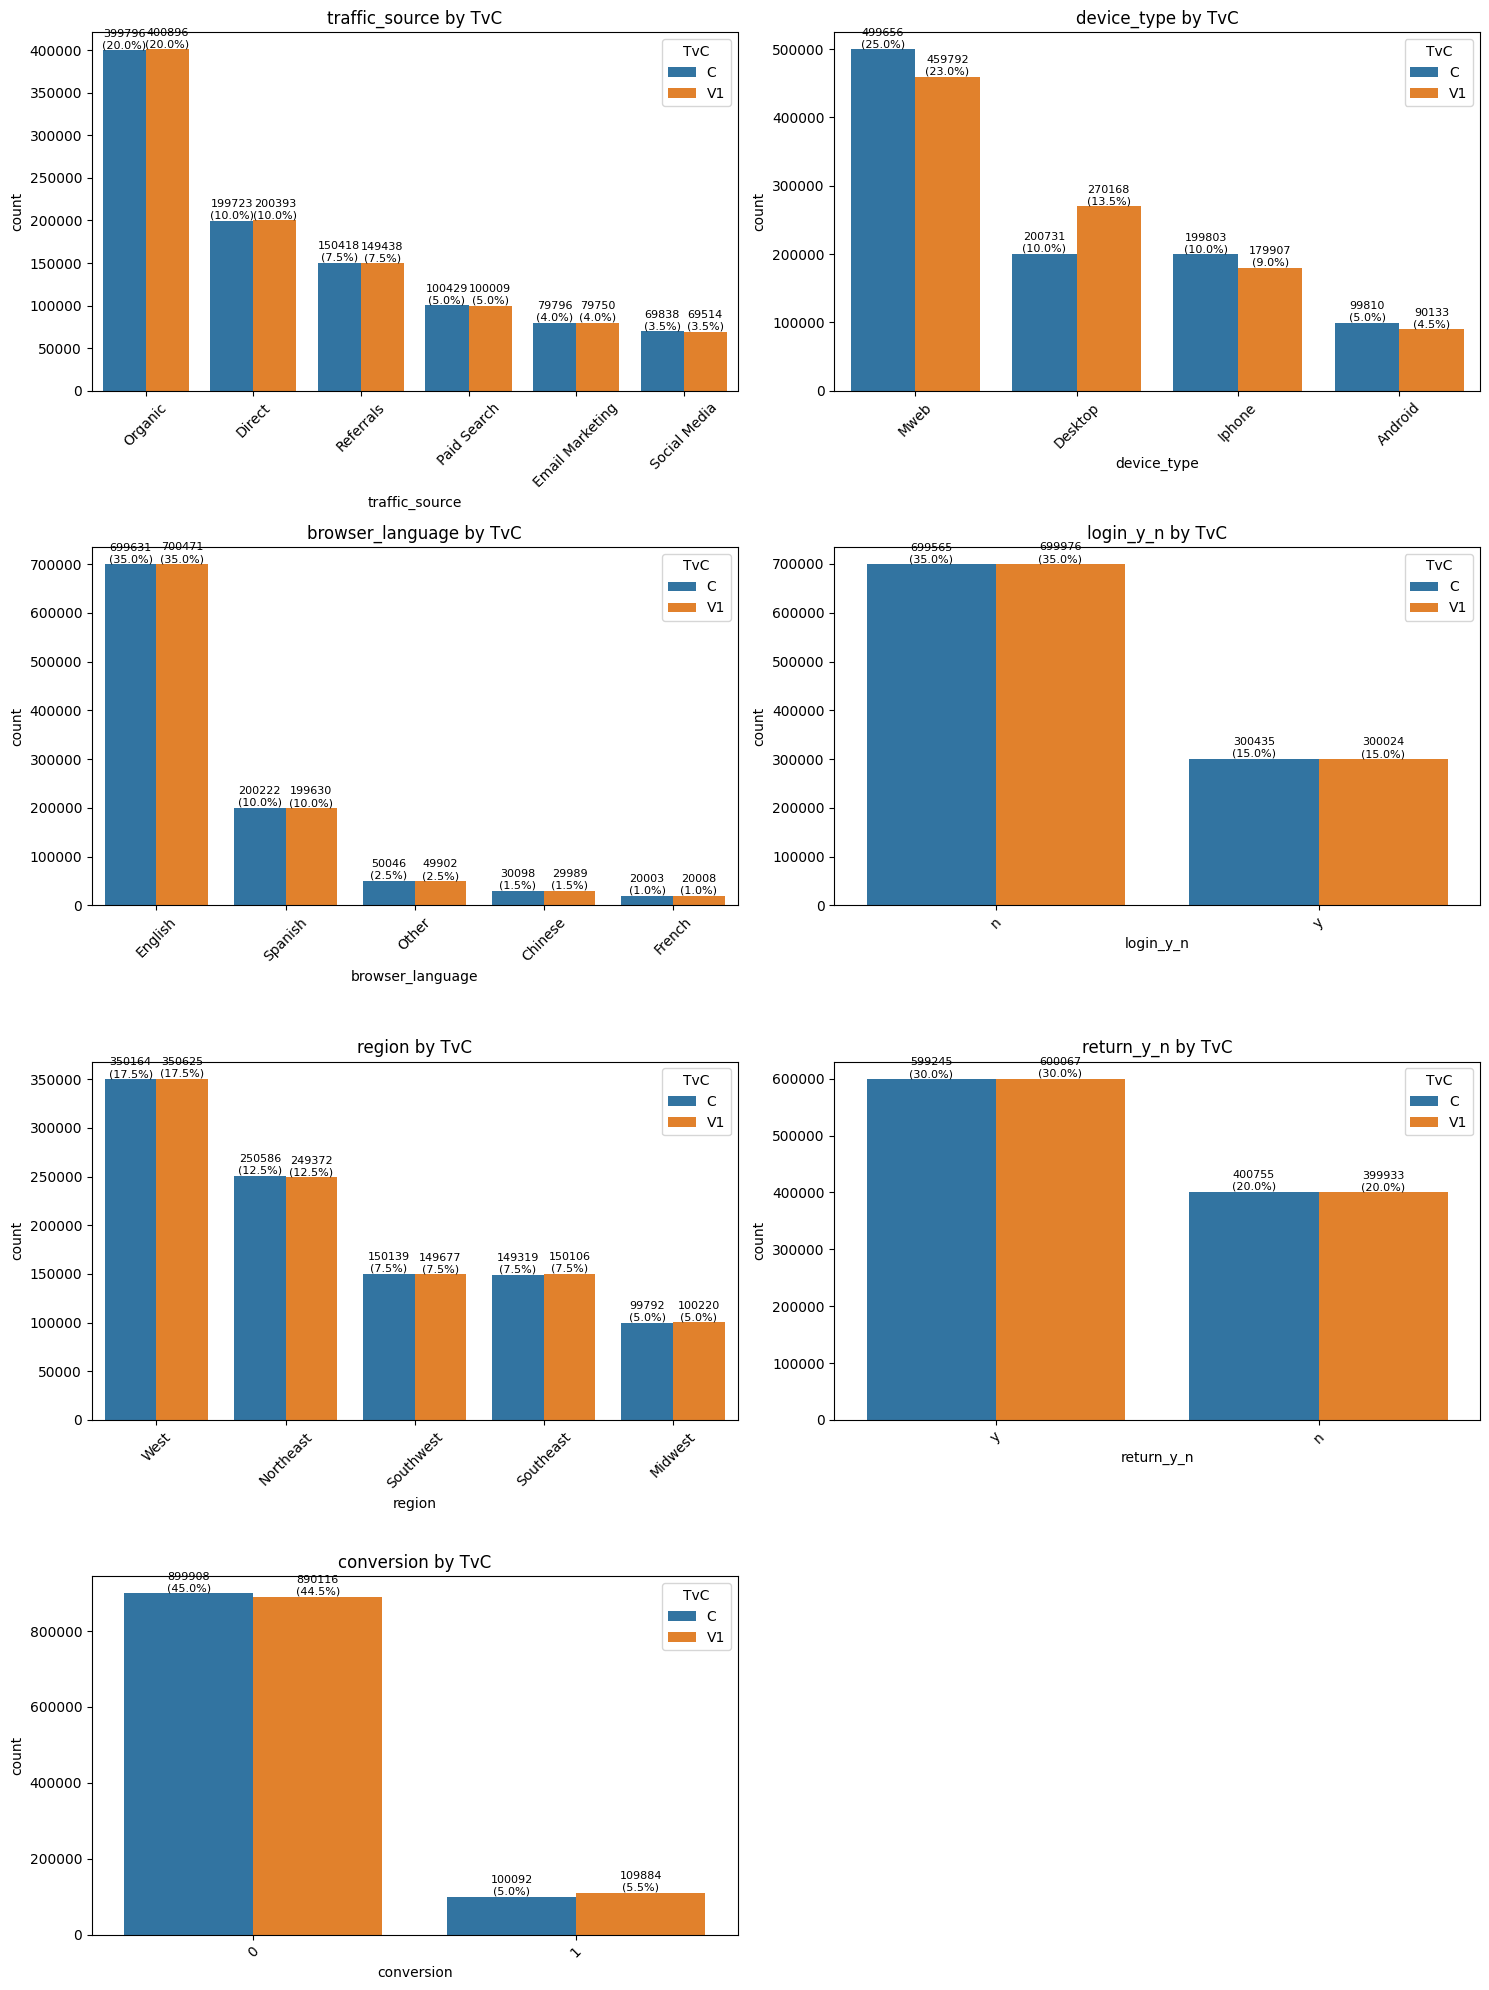

In [33]:
# ============================
# TvC 그룹별 사용자 특성 분포 확인
# ============================

analysis_cols = commerce.columns.drop(['date','TvC'])

plot_count_distribution(
    commerce,
    analysis_cols,
    hue='TvC'
)

### 2-3. 구매 전환 별 사용자 특성 분포 확인

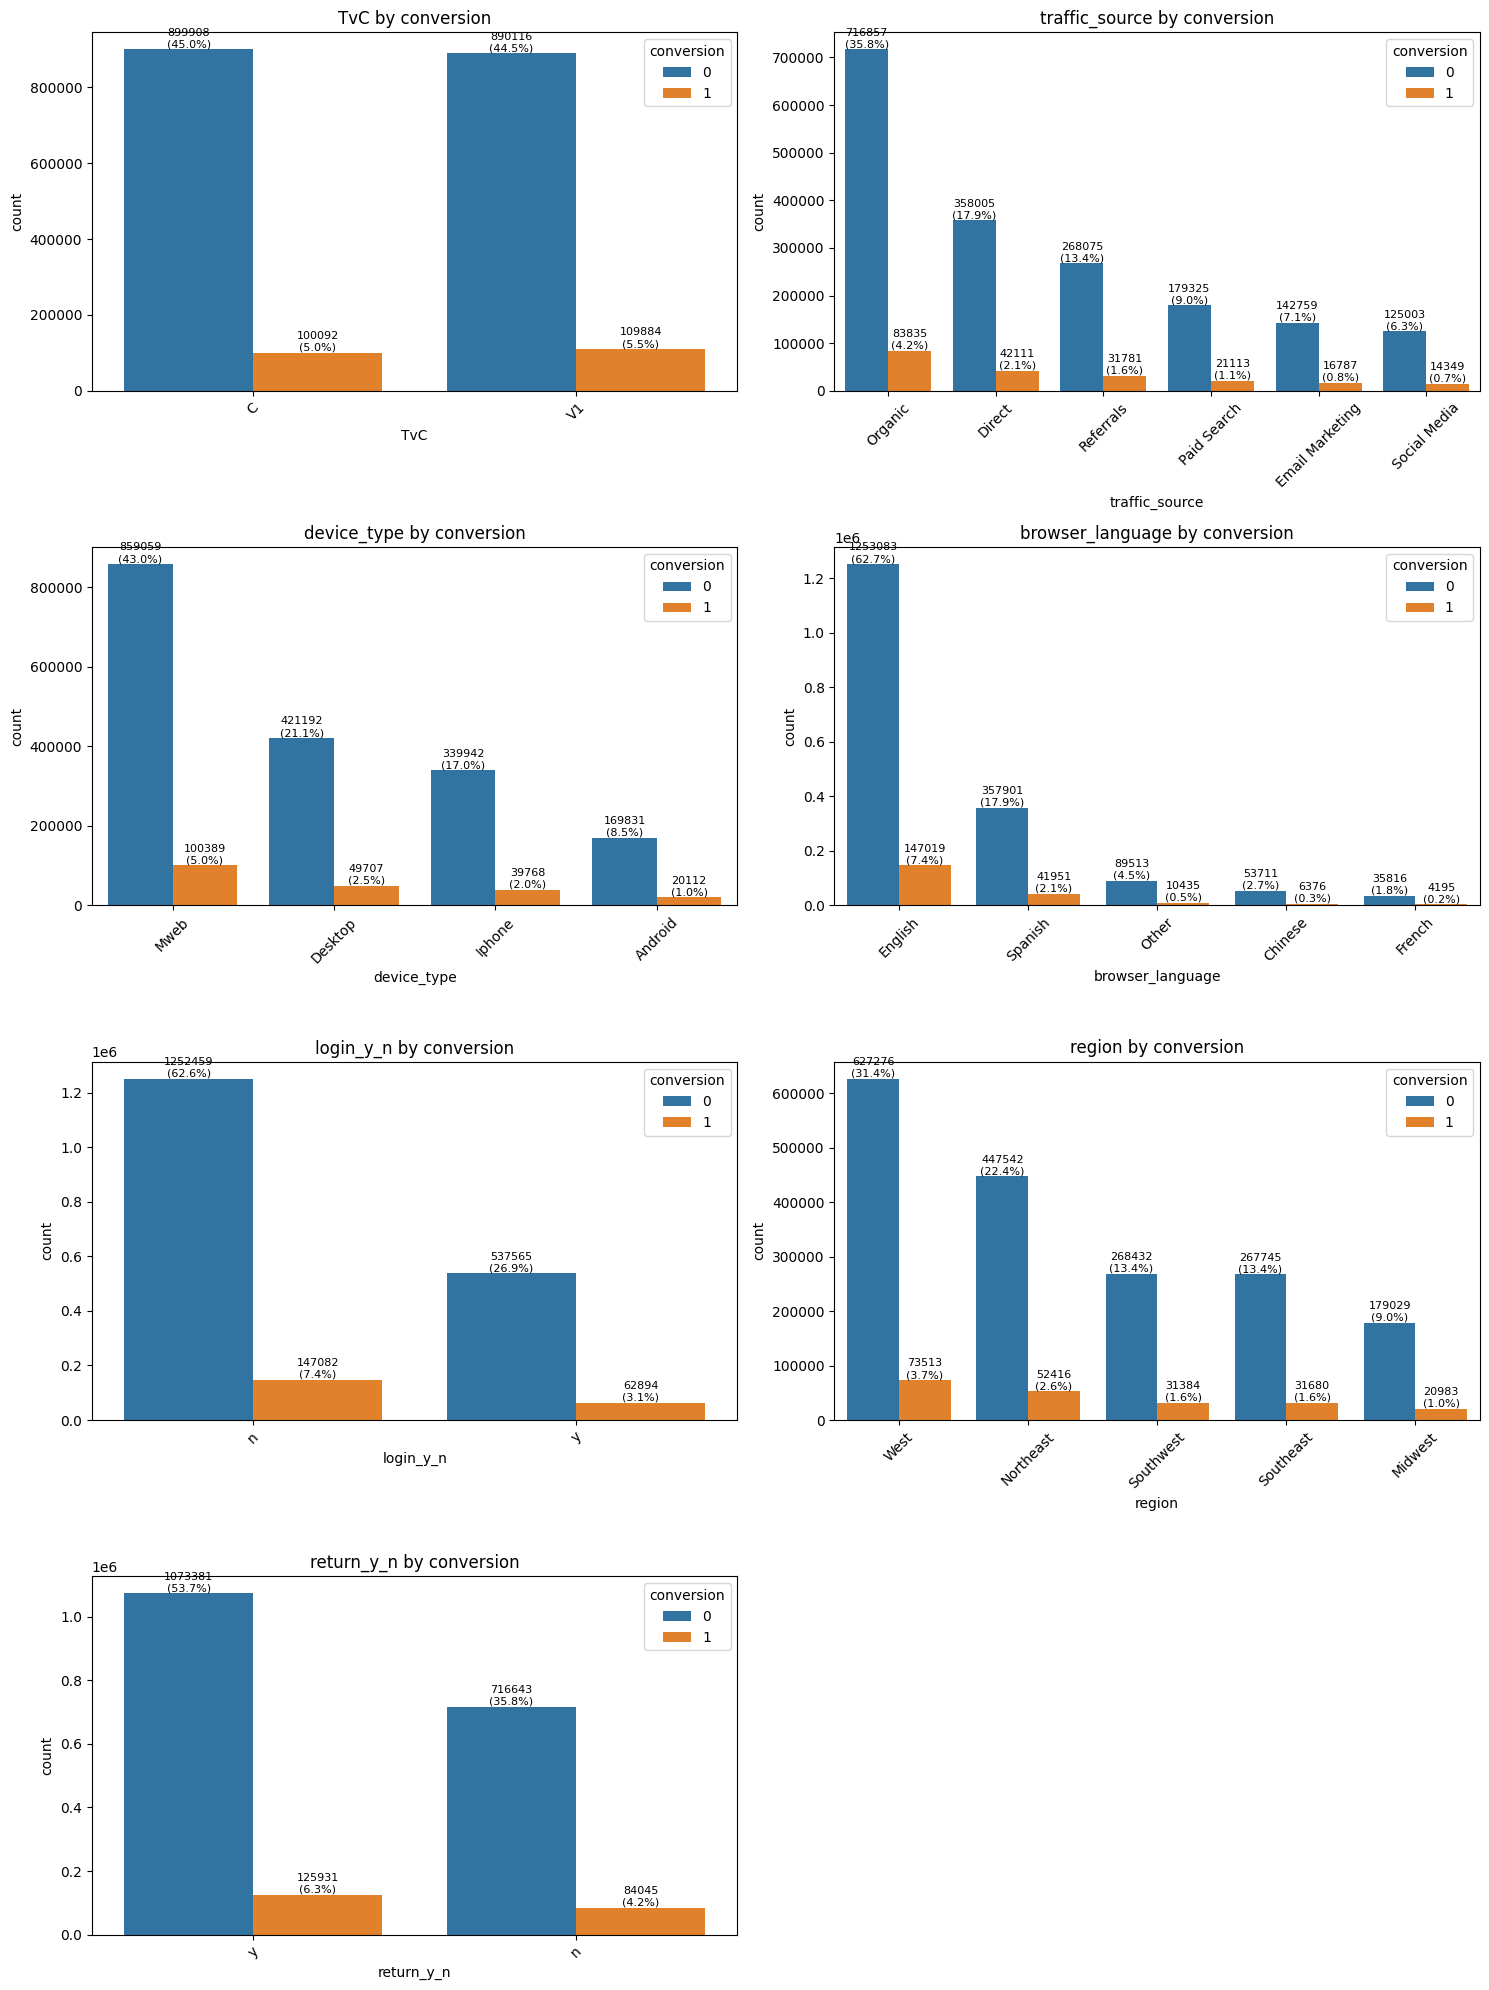

In [34]:
# ============================
# TvC 그룹별 사용자 특성 분포 확인
# ============================

analysis_cols = commerce.columns.drop(
    ['date', 'conversion']
)

plot_count_distribution(
    commerce,
    analysis_cols,
    hue='conversion'
)

### 2-4. 날짜별 데이터 분포 확인

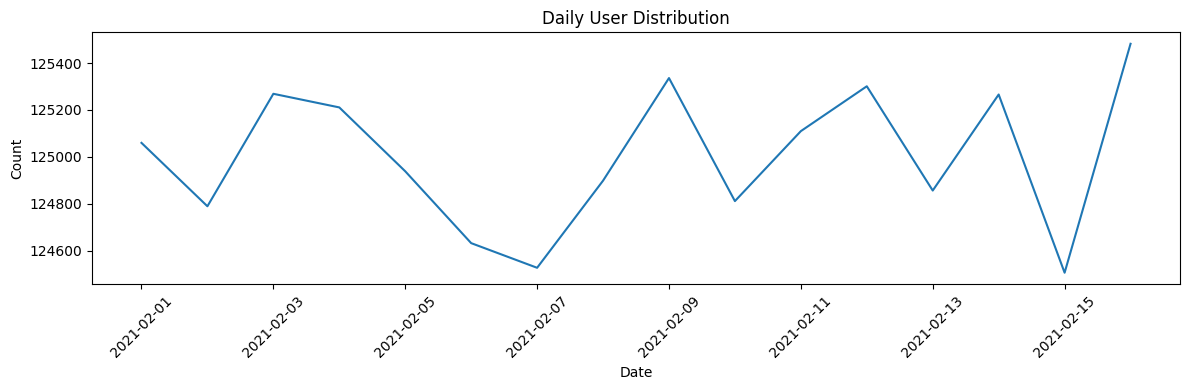

In [35]:
# ============================
# 날짜별 데이터 분포 확인
# ============================

date_count = (
    commerce['date']
    .value_counts()
    .sort_index()
)


plt.figure(figsize=(12, 4))


sns.lineplot(
    x=date_count.index,
    y=date_count.values
)


plt.title('Daily User Distribution')

plt.xlabel('Date')
plt.ylabel('Count')


plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## 3.A/B 테스트 통계 검정


- 랜덤 배정 검증
    - TvC 그룹 간 사용자 특성 분포 균형 확인
    - Chi-square Test + Cramer's V
- 핵심 KPI 효과 검증
    - TvC 그룹 간 구매 전환율 차이 확인
    - Chi-square Test + Cramer's V
- 세그먼트별 A/B Test
    - 사용자 특성별 V1 효과 확인
- 상호작용 검증
    - V1 효과가 특정 사용자군에서 다르게 나타나는지 확인
    - Logistic Regression

### 가설 검정 기본 함수

In [36]:
# ============================
# 카이제곱 검정 및 효과크기 계산 함수
# ============================

def chi_square_test(table) :
  # 카이제곱 검정 수행
  chi2, p, dof, expected = chi2_contingency(table)

  # Cramer's V 계산
  n = table.values.sum()
  r,k = table.shape

  cramers_v = np.sqrt(
      (chi2/n) /
      min(r-1,k-1)
  )

  return chi2, p, dof, expected, cramers_v

In [37]:
# ============================
# 효과크기 해석 함수
# ============================

def interpret_effect_size(value) :
  if value < 0.1 :
    return '매우 작음'
  elif value < 0.3 :
    return '작음'
  elif value < 0.5 :
    return '보통'
  else :
    return '큼'

### 3-1. 실험 데이터 사전 검증
- 날짜별 데이터 분포 확인
- 날짜별 전환율 차이 검증

In [58]:
# ============================
# 날짜별 사용자 수 분포 확인
# ============================

daily_user = (
    commerce
    .groupby(['date','TvC'])
    .size()
    .unstack()
)

daily_user

TvC,C,V1
date,,
2021-02-01,62392,62668
2021-02-02,62573,62217
2021-02-03,62557,62712
2021-02-04,62665,62546
2021-02-05,62472,62467
2021-02-06,61949,62684
2021-02-07,62057,62471
2021-02-08,62343,62556
2021-02-09,62698,62638


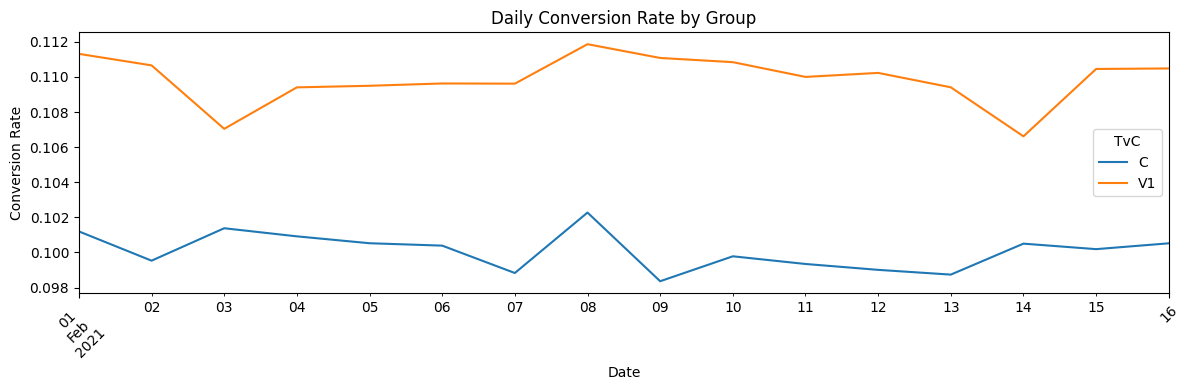

In [59]:
# ============================
# 날짜별 그룹별 전환율 확인
# ============================

daily_conversion = (
    commerce
    .groupby(['date','TvC'])['conversion']
    .mean()
    .unstack()
)

daily_conversion.plot(
    figsize=(12,4),
    title='Daily Conversion Rate by Group'
)

plt.ylabel('Conversion Rate')
plt.xlabel('Date')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [60]:
# ============================
# 날짜에 따른 구매 전환 영향 검증
# ============================

table = pd.crosstab(
    commerce['date'],
    commerce['conversion']
)

chi2, p, dof, expected, cramers_v = chi_square_test(table)

print('='*60)

print('날짜 영향 검증 결과')

print(f'Chi-square: {chi2:.3f}')
print(f'p-value: {p:.4f}')
print(f'효과크기 : {interpret_effect_size(cramers_v)}')

if p < 0.05:
    print(' -> 날짜별 구매 전환 여부 차이는 통계적으로 유의함')
else:
    print(' -> 날짜별 구매 전환 여부 차이는 통계적으로 유의하지 않음')

날짜 영향 검증 결과
Chi-square: 14.439
p-value: 0.4925
효과크기 : 매우 작음
 -> 날짜별 구매 전환 여부 차이는 통계적으로 유의하지 않음


#### 결과 : 날짜 영향 검증(Date <-> Conversion)

- 날짜별 구매 전환 여부 차이를 검정한 결과 p-value = 0.4925로 나타나 통계적으로 유의한 차이는 확인되지 않음

- 또한 Cramer's V는 매우 작은 수준으로 나타나 날짜에 따른 구매 전환 차이의 영향 크기는 제한적인 것으로 판단

- 따라서 실험 기간 내 날짜 변화가 구매 전환 결과에 미치는 영향은 크지 않은 것으로 판단하여 이후 A/B 테스트 분석에서는 date 변수를 제외하고 사용자 특성 및 실험 그룹(TvC) 중심으로 분석 진행

### 3-2. 랜덤 배정 검증(TvC <-> 사용자 특성 변수)


In [38]:
# ============================
# 랜덤 배정 검증
# ============================

analysis_cols = commerce.columns.drop(
    ['TvC','date','conversion']
)

for col in analysis_cols :
    # 교차표 생성
    table = pd.crosstab(
        commerce[col],
        commerce['TvC']
    )

    chi2, p, dof, expected, cramers_v = chi_square_test(table)

    print('='*60)
    print(f'변수명 : {col}')
    print(f'Chi-square: {chi2:.3f}')
    print(f'p-value: {p:.4f}')
    print(
        f'효과크기 : {interpret_effect_size(cramers_v)}'
    )

    if p < 0.05 :
        print(' -> C와 V1 그룹 간 분포 차이가 통계적으로 유의함')
    else :
        print(' -> C와 V1 그룹 간 분포 차이가 통계적으로 유의하지 않음')

변수명 : traffic_source
Chi-square: 7.483
p-value: 0.1871
효과크기 : 매우 작음
 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의하지 않음
변수명 : device_type
Chi-square: 13430.746
p-value: 0.0000
효과크기 : 매우 작음
 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의함
변수명 : browser_language
Chi-square: 1.786
p-value: 0.7750
효과크기 : 매우 작음
 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의하지 않음
변수명 : login_y_n
Chi-square: 0.400
p-value: 0.5271
효과크기 : 매우 작음
 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의하지 않음
변수명 : region
Chi-square: 6.947
p-value: 0.1387
효과크기 : 매우 작음
 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의하지 않음
변수명 : return_y_n
Chi-square: 1.404
p-value: 0.2361
효과크기 : 매우 작음
 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의하지 않음


In [39]:
# device_type 그룹별 구성 비율 확인

pd.crosstab(
    commerce["device_type"],
    commerce["TvC"],
    normalize="columns"
)

TvC,C,V1
device_type,,
Android,0.099810,0.090133
Desktop,0.200731,0.270168
Iphone,0.199803,0.179907
Mweb,0.499656,0.459792


#### 결과 : 랜덤 배정 검증(TvC <-> 사용자 특성 변수)


- 대부분의 사용자 특성 변수에서 C와 V1 그룹 간 통계적으로 유의한 분포 차이가 확인X

- device_type 변수에서만 C와 V1 그룹 간 통계적으로 유의한 차이가 확인
  - 다만, Cramer's V는 0.0819로 나타나 device_type 구성 차이의 크기는 매우 작은 수준으로 판단
  - 실제 그룹별 비율을 확인한 결과, Desktop 비율을 V1 그룹에서 높고, Mweb 비율을 C그룹에서 높음
- 따라서 일부 device_type 구성 차이는 존재하미나, 전체적으로 C와 V1 그룹은 사용자 특성 기준에서 비교 가능한 수준으로 판단

- 이후 C와 V1 간 핵심 KPI 효과 검정 및 세그먼트별 A/B 테스트를 모든 변수 진행

### 3-3. 핵심 KPI 효과 검증(TvC <-> Conversion)

In [40]:
# ============================
# 그룹별 구매 전환율 확인
# ============================

conversion_rate = (
    commerce.groupby('TvC')['conversion'].mean()
)

c_rate = conversion_rate['C']
v1_rate = conversion_rate['V1']

print('그룹별 전환율')
print(conversion_rate)

print('='*60)

print(f'C 전환율 : {c_rate*100:.2f}%')
print(f'V1 전환율 : {v1_rate*100:.2f}%')
print(f"전환율 차이 : {(v1_rate-c_rate)*100:.2f}%p")

그룹별 전환율
TvC
C     0.100092
V1    0.109884
Name: conversion, dtype: float64
C 전환율 : 10.01%
V1 전환율 : 10.99%
전환율 차이 : 0.98%p


In [41]:
# ============================
# 카이제곱 검정
# ============================

table = pd.crosstab(
    commerce['TvC'],
    commerce['conversion']
)

chi2, p, dof, expected, cramers_v = chi_square_test(table)

print('='*60)

print('교차표')
print(table)

print('='*60)

print('기대빈도')
expected_df = pd.DataFrame(
    expected,
    index=table.index,
    columns = table.columns
)
print(expected_df)

print('='*60)

print('카이제곱 검정 결과')

print(f'Chi-square: {chi2:.3f}')
print(f'p-value: {p:.4f}')
print(f"Cramer's V : {cramers_v:.4f}\n")
if p < 0.05 :
    print(' -> C와 V1 그룹 간 분포 차이가 통계적으로 유의함')
else :
    print(' -> C와 V1 그룹 간 분포 차이가 통계적으로 유의하지 않음')

print(f'효과크기 : {interpret_effect_size(cramers_v)}')


# 잔차 분석
# residual > 0 → 기대보다 많이 발생
# residual < 0 → 기대보다 적게 발생
# |residual| > 2 → 의미 있는 차이
print('='*60)

residuals = (table - expected_df) / np.sqrt(expected_df)
print('표준화 잔차')
print(residuals)

교차표
conversion       0       1
TvC                       
C           899908  100092
V1          890116  109884
기대빈도
conversion         0         1
TvC                           
C           895012.0  104988.0
V1          895012.0  104988.0
카이제곱 검정 결과
Chi-square: 510.100
p-value: 0.0000
Cramer's V : 0.0160

 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의함
효과크기 : 매우 작음
표준화 잔차
conversion         0          1
TvC                            
C           5.175198 -15.110247
V1         -5.175198  15.110247


In [42]:
# ============================
# 전환율 차이 95% 신뢰구간
# ============================

from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep


count = np.array([
    table.loc['C',1],
    table.loc['V1',1]
])

nobs = np.array([
    table.loc['C'].sum(),
    table.loc['V1'].sum()
])


ci_low, ci_high = confint_proportions_2indep(
    count[1],
    nobs[1],
    count[0],
    nobs[0],
    method='wald'
)

print(f'전환율 차이 95% 신뢰구간 : {ci_low*100:.2f}%p ~ {ci_high*100:.2f}%p')

전환율 차이 95% 신뢰구간 : 0.89%p ~ 1.06%p


#### 결과 : 핵심 KPI 효과 검정(TvC <-> Conversion)


- C 전환율 : 10.01% / V1 전환율 : 10.99%
  - V1 그룹은 C그룹 대비 전환율이 0.98%p 증가한 것으로 확인

- 카이제곱 검정 결과 p-value < 0.05로 나타나 C와 V1 간 구매 전환 차이는 통계적으로 유의함을 확인

- 다만, Cramer's V는 0.016으로 효과크기는 매우 작게 나타나 통계적으로 유의한 차이는 존재하지만, 그룹 간 전환율 차이의 실제 영향 크기는 제한적인 수준으로 판단

- 잔차 분석 결과 C 그룹에서는 기대 대비 구매 전환이 적게 발생했으며, V1 그룹에서는 기대 대비 구매 전환이 많이 발생하여 카이제곱 검정 결과에 영향을 준 것으로 확인

- V1 적용 시 전환율 개선 효과는 95% 신뢰구간 기준 약 0.89%p ~ 1.06%p 범위에서 발생할 것으로 추정
    - 신뢰구간 전체가 0보다 큰 값을 포함하므로 V1 전환율 개선 효과는 통계적으로 유의하여 실제 서비스에서도 양의 효과가 발생할 가능성이 높다



### 3-4. 변수별 A/B 테스트

In [43]:
# ============================
# 세그먼트별 전환율 비교
# ============================

analysis_cols = commerce.columns.drop(
    ['TvC', 'date', 'conversion']
)

for col in analysis_cols:
    print(f'변수명 : {col}')

    # 세그먼트별 그룹 전환율 계산
    result = (
        commerce
        .groupby([col, 'TvC'])['conversion']
        .mean()
        .unstack()
    )

    # 전환율 차이 계산
    result['C'] = result['C'] * 100
    result['V1'] = result['V1'] * 100
    result['차이(%p)'] = (result['V1'] - result['C'])
    result['상대 차이(%)'] = (result['차이(%p)'] / result['C'] * 100)

    # 출력 컬럼 정리
    result = (result[['C', 'V1', '차이(%p)', '상대 차이(%)']].round(2))
    print(result)
    print('--' * 40)

변수명 : traffic_source
TvC                  C     V1  차이(%p)  상대 차이(%)
traffic_source                                 
Direct           10.03  11.02    0.99      9.87
Email Marketing   9.97  11.07    1.11     11.09
Organic          10.00  10.94    0.95      9.46
Paid Search      10.00  11.07    1.07     10.75
Referrals        10.17  11.03    0.86      8.49
Social Media      9.74  10.85    1.11     11.38
--------------------------------------------------------------------------------
변수명 : device_type
TvC              C     V1  차이(%p)  상대 차이(%)
device_type                                
Android      10.06  11.17    1.11     11.07
Desktop       9.94  11.02    1.08     10.86
Iphone       10.01  10.99    0.98      9.81
Mweb         10.03  10.94    0.91      9.04
--------------------------------------------------------------------------------
변수명 : browser_language
TvC                   C     V1  차이(%p)  상대 차이(%)
browser_language                                
Chinese           10.21  11.01

In [44]:
# ============================
# 세그먼트별 통계 검정
# ============================

for col in analysis_cols :
    for segment in commerce[col].unique() :
        temp = commerce[commerce[col] == segment]
        table = pd.crosstab(temp['TvC'],temp['conversion'])

        chi2, p, dof, expected,cramers_v = chi_square_test(table)

        print('='*60)
        print(f'변수명 : {col}')
        print(f'세그먼트 : {segment}')
        print(f'Chi-square: {chi2:.3f}')
        print(f'p-value: {p:.4f}')
        print(f'Cramer\'s V : {cramers_v:.4f}')
        if p < 0.05 :
            print(' -> C와 V1 그룹 간 분포 차이가 통계적으로 유의함')
        else :
            print(' -> C와 V1 그룹 간 분포 차이가 통계적으로 유의하지 않음')
        print(f'효과크기 : {interpret_effect_size(cramers_v)}')

변수명 : traffic_source
세그먼트 : Referrals
Chi-square: 58.921
p-value: 0.0000
Cramer's V : 0.0140
 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의함
효과크기 : 매우 작음
변수명 : traffic_source
세그먼트 : Direct
Chi-square: 103.994
p-value: 0.0000
Cramer's V : 0.0161
 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의함
효과크기 : 매우 작음
변수명 : traffic_source
세그먼트 : Email Marketing
Chi-square: 51.654
p-value: 0.0000
Cramer's V : 0.0180
 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의함
효과크기 : 매우 작음
변수명 : traffic_source
세그먼트 : Paid Search
Chi-square: 61.321
p-value: 0.0000
Cramer's V : 0.0175
 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의함
효과크기 : 매우 작음
변수명 : traffic_source
세그먼트 : Organic
Chi-square: 190.854
p-value: 0.0000
Cramer's V : 0.0154
 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의함
효과크기 : 매우 작음
변수명 : traffic_source
세그먼트 : Social Media
Chi-square: 46.226
p-value: 0.0000
Cramer's V : 0.0182
 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의함
효과크기 : 매우 작음
변수명 : device_type
세그먼트 : Mweb
Chi-square: 210.016
p-value: 0.0000
Cramer's V : 0.0148
 -> C와 V1 그룹 간 분포 차이가 통계적으로 유의함
효과크기 : 매우 작음
변수명 : device_type
세그먼트 : Iphone
C

#### 결과 : 변수별 A/B 테스트

- 모든 사용자 세그먼트에서 V1 그룹의 전환율이 C그룹보다 높게 나타났으며, 모든 세그먼트에서 통계적으로 유의한 차이가 확인되었다

- 세그먼트별 전환율 개선폭은 약 0.80%p ~ 1.19%p 수준으로 나타났으며, 특정 변수 조합에서 추가적은 상승 효과는 확인되지 않았다

- 가장 높은 전환율 개선은 region = Southeast에서 나타났다
    - C 전환율 : 9.98%
    - V1 전환율 : 11.17%
    - 개선폭 : 1.19%p

- 모든 세그먼트에서 Cramer's V가 0.1 미만으로 나타나 효과크기는 매우 작은 수준이었다.

- 따라서 V1의 전환율 개선 효과는 특정 사용자 특성에 한정되어 나타난 것이 아니라, 여러 사용자 세그먼트에서 일관된 방향으로 확인되었다

- 다만 세그먼트별로 다수의 통계 검정을 수행했으므로 다중 검정에 따른 유의수준 해석에는 주의가 필요하며, 본 분석에서는 효과의 방향과 효과크기를 함께 고려하여 결과를 해석

### 3-5. 상호작용


In [45]:
# ============================
# 상호작용 분석
# ============================

# statsmodels formula 사용을 위한 변수명 변경
df_model = commerce.rename(
    columns = {
        'TvC' : 'tvc',
        'device_type' : 'device'}
)

# TvC X Device, TvC X Region 상호작용을 포함한 로지스틱 회귀
model = smf.logit(
    'conversion ~ tvc * device + tvc * region',
    data = df_model
).fit()

# 회귀 결과 확인
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.335775
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             conversion   No. Observations:              2000000
Model:                          Logit   Df Residuals:                  1999984
Method:                           MLE   Df Model:                           15
Date:                Sat, 18 Jul 2026   Pseudo R-squ.:               0.0003910
Time:                        09:16:26   Log-Likelihood:            -6.7155e+05
converged:                       True   LL-Null:                   -6.7181e+05
Covariance Type:            nonrobust   LLR p-value:                2.357e-102
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -2.1977      0.015   -151.122      0.

#### 결과 : 상호작용(TvC x Device / TvC x Region)



- 상호작용 검증 변수 선정 기준
    - device_type
        - 랜덤 배정 검증 결과 C와 V1 그룹 간 유일하게 통계적 차이가 확인된 변수
        - 다만 Cramer's V 는 0.0819로 효과크기는 매우 작아, 실험 결과에 영향을 줄 가능성을 추가 검증하기 위해 선정
    - region
        - 세그먼트별 A/B 테스트 결과 가장 높은 전환율 개선폭(1.19%p)을 보인 Southeast가 존재해 지역별 V1 효과 차이를 확인하기 위해 선정

- 로지스틱 회귀 결과
    - TvC[T.v1]의 p-value는 0.000으로 나타나 사용자 특성을 통제한 이후에도 V1 그룹의 전환 개선 효과는 통계적으로 유의함을 확인

- 하지만, TvC x Device, TvC x Region 상호작용 항의 p-value는 모두 0.05 이상으로 나타남
    - Device 유형에 따라 V1 효과 크기가 달라진다는 통계적 근거 없음
    - Region에 따라 V1 효과 크기가 달라진다는 통계적 근거 없음

- 따라서 V1 적용 효과는 특정 Device 또는 Region 사용자에게만 발생한 것이 아닌, 전체 사용자 그룹에서 일관된 방향으로 나타난 것으로 판단

- 로지스틱 회귀 모델의 Pseudo R²는 0.00039로 낮게 나타났으며, 이는 device와 region 같은 사용자 특성 변수가 구매 전환 자체를 설명하는 정도는 제한적임을 의미
    - 다만 본 분석의 목적은 구매 예측이 아닌 V1 적용 효과와 효과 차이 여부 검증이므로, 모델의 예측력보다 TvC 계수와 상효작용 항의 통계적 유의성을 중심으로 해석

##4.기대효과

In [46]:
# ============================
# 기대 효과 산출
# ============================

# 전체 사용자 수
total_user = len(commerce)

# 그룹별 전환율 계산
c_conversion = commerce[commerce['TvC']=='C']['conversion'].mean()
v1_conversion = commerce[commerce['TvC']=='V1']['conversion'].mean()

# 전환율 개선 효과
conversion_diff = v1_conversion - c_conversion

relative_lift = (
    conversion_diff / c_conversion
) * 100

# 예상 구매 건수 계산
expected_c_purchase = total_user * c_conversion
expected_v1_purchase = total_user * v1_conversion

expected_additional_purchases = (expected_v1_purchase- expected_c_purchase)

print(f'전체 사용자 수 : {total_user:,}')

print('='*50)

print(f'C 그룹 전환율 : {c_conversion*100:.2f}%')
print(f'V1 그룹 전환율 : {v1_conversion*100:.2f}%')
print(f'전환율 개선폭 : {conversion_diff*100:.2f}%p')
print(f'상대 개선율 : {relative_lift:.2f}%')

print('='*50)

print(f'C 적용 예상 구매 수 : {expected_c_purchase:,.0f}')
print(f'V1 적용 예상 구매 수 : {expected_v1_purchase:,.0f}')
print(f'추가 구매 예상 수 : {expected_additional_purchases:,.0f}')

전체 사용자 수 : 2,000,000
C 그룹 전환율 : 10.01%
V1 그룹 전환율 : 10.99%
전환율 개선폭 : 0.98%p
상대 개선율 : 9.78%
C 적용 예상 구매 수 : 200,184
V1 적용 예상 구매 수 : 219,768
추가 구매 예상 수 : 19,584


### 결과 : 기대효과

- 전체 사용자에게 V1을 적용할 경우 기존 C 그룹 대비 전환율은 약 +0.98%p 개선될 것으로 예상
    - 기존 C그룹 대비 상대 전환율이 약 9.78% 개선되었다

- 동일한 사용자 규모 기준:
    - 기존 C 적용 예상 구매 수 : 약 100,092건
    - V1 적용 예상 구매 수 : 약 109,884건

- 따라서 전체 사용자에게 V1을 적용할 경우 약 9,792건의 추가 구매 전환 효과가 기대됨
    - 해당 기대효과는 A/B 테스트 수행 기간 동안 발생한 전체 사용자 규모를 기준으로 산출한 값으로, 실제 서비스 적용 시 트래픽 규모와 기간에 따라 달라질 수 있음

- 다만 해당 값은 실험 기간 내 사용자 규모를 기준으로 산출한 예상치이며, 실제 서비스 적용 시 트래픽 규모 및 사용자 구성 변화에 따라 달라질 수 있음

##5.최종 분석 결과 및 제안

1. 실험 신뢰성 확보
- 랜덤 배정 검증 결과 대부분 특성에서 C와 V1 그룹 간 분포 차이가 없었으며, device_type만 통계적으로 차이가 있었지만 효과크기(Cramer's V = 0.0819)는 매우 작았다
- 이후 상호작용 분석에서도 Device에 따른 V1 효과 차이는 확인되지 않아 실험 결과에 큰 영향을 주지 않는 것으로 판단

2. V1은 구매 전환율을 유의하게 향상
- V1 그룹의 구매 전환율을 10.99%, C그룹은 10.01%로 0.98%p 증가하였다
- 카이제곱 검정 결과 두 그룹의 차이는 통계적으로 유의(p<0.05)하였다
- 95% 신뢰구간에서도 전환율 개선 효과가 0보다 큰 범위(0.89~1.06%p)로 나타나 효과의 신뢰성을 확인하였다

3. 특정 사용자에게만 효과가 나타나지 않았다
- 모든 사용자 세그먼트에서 V1의 전환율이 C보다 높게 나타났다
- 상호작용 분석 결과 Device 및 Region에 따른 효과 차이는 통계적으로 확인되지 않았다
- 따라서 V1 효과는 특정 집단이 아닌 전체 사용자에게 일관된 개선 효과가 나타난 것으로 판단하였다

4. 기대효과
- 전체 사용자에게 V1을 적용할 경우
    - 전환율 약 0.98%p 증가
        - 상대 개선율 약 9.78%
    - **추가 구매 약 9,792건 발생이 기대**된다


💡최종 제안
- 본 A/B 테스트 결과를 종합하면 V1은 구매 전환율을 통계적으로 유의하게 개선하였으며, 특정 사용자군에 국한되지 않고 전체 사용자에게 유사한 개선 효과가 나타났으므로 **서비스 전체에 V1을 적용하는 것을 제안한다.**